# Analysis of discharge

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from config import *

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
# List of possible parameters
parameters = [
    "WTemp_C", "SpC_uScm", "DO_mgL", "pH",
    "Turb_FNU", "Turb_NTU", "NO3_mgNL",
    "fDOM_QSU", "fDOM_RFU", "DOC_mgL",
    "PO4_mgL", "Chla_ugL", "Chla_RFU",
    "PC_ugL", "PC_RFU"
]

In [3]:
# Processing metadata, isolating specific parameters
md_wide = pd.read_csv(metadata_filepath+"metadata.csv", dtype = {'sourceID': str})
print(f"Full dataset size: {md_wide.shape[0]}")
params = ['SpC_uScm','DO_mgL','Turb_FNU']

for param in params:
    md_wide[param] = md_wide['WQ_parameters'].str.contains(param)

# Removing the stations without data
md_wide = md_wide[(md_wide['SpC_uScm']) | (md_wide['DO_mgL']) | (md_wide['Turb_FNU'])]
print(f"Filtered dataset size: {md_wide.shape[0]}")

Full dataset size: 870
Filtered dataset size: 556


In [4]:
md_wide.head()

,STREAM_ID,sourceID,source,site name,latitude_wgs84,longitude_wgs84,drainagearea_sqkm,state_name,time_zone,WQ_parameters,SpC_uScm,DO_mgL,Turb_FNU
0,STREAM-gauge-309,7374525,USGS,"Mississippi River at Belle Chasse, LA",29.857151,-89.977847,2926688.700,Louisiana,Central,Turb_FNU,False,False,True
1,STREAM-gauge-308,7374000,USGS,"Mississippi River at Baton Rouge, LA",30.445667,-91.191556,2915836.642,Louisiana,Central,"WTemp_C,SpC_uScm,DO_mgL,pH,Turb_FNU,NO3_mgNL",True,True,True
3,STREAM-gauge-2530,7032000,USGS,"MISSISSIPPI RIVER AT MEMPHIS, TN",35.123146,-90.077592,2415942.672,Tennessee,Central,Turb_FNU,False,False,True
5,STREAM-gauge-2203,6934500,USGS,"Missouri River at Hermann, MO",38.709806,-91.438500,1353269.775,Missouri,Central,"WTemp_C,SpC_uScm,DO_mgL,pH,Turb_FNU,NO3_mgNL,f...",True,True,True
8,STREAM-gauge-2191,6894650,USGS,"Missouri River at Napoleon, MO",39.133611,-94.063889,1256404.149,Missouri,Central,"WTemp_C,SpC_uScm,DO_mgL,pH,Turb_FNU,NO3_mgNL",True,True,True


# Sampling Coverage Across Flow Regime

In [9]:
# Number of bins for the flow distribution (20 bins = 5% increments)
n_bins = 20
bin_edges_pct = np.linspace(0, 1, n_bins + 1)
bin_labels = [f'{int(bin_edges_pct[i]*100)}-{int(bin_edges_pct[i+1]*100)}'
              for i in range(n_bins)]

# Bulding the dataframe
results = []
missing_flow = 0
# Iterate over each row and calculate
for i, row in md_wide.iterrows():
    try:
        site = row['STREAM_ID']
        wq_para_data = pd.read_csv(water_quality_filepath+site+'.csv')
        q_data  = pd.read_csv(discharge_filepath+site+'.csv')
        
        # Determine distribution of flow. This should be done with a longer period of record, but for now we will leave it. 
        Q_percentiles = np.quantile(q_data['Q_m3s'].dropna(), bin_edges_pct)
        
        # Identify which parameters are available
        wq_params = [col for col in wq_para_data.columns 
                     if col != 'DateTime' and not col.startswith('Flag_')]
        
        for param in wq_params:
            wq_para_i = wq_para_data[['DateTime', param]].copy()
            wq_para_i.dropna(subset = [param], inplace=True)
            wq_para_i = wq_para_i.merge(q_data, on='DateTime', how='left')
            wq_para_i.dropna(subset=['Q_m3s'], inplace=True)
            
            if wq_para_i.empty:
                continue
            
            # Binning the sample flow based on percentile 
            wq_para_i['bins'] = pd.cut(wq_para_i['Q_m3s'], 
                                       bins=Q_percentiles,
                                       labels=bin_labels,
                                       include_lowest=True,
                                       duplicates='drop')
            
            # Count samples per flow bin
            counts = wq_para_i['bins'].value_counts().reindex(bin_labels, fill_value=0)
            
            result_row = {
                'STREAM_ID': site,
                'param': param,
                'n_samples': int(counts.sum())
            }
            for label in bin_labels:
                result_row[label] = counts[label]
            results.append(result_row)
    except:
        missing_flow+=1  
df_results = results
print(f"Missing flow for {np.round((missing_flow/len(md_wide))*100,1)}% of stations.")

C:\Users\dkbyrnes\AppData\Local\Temp\ipykernel_12756\820854511.py:14: DtypeWarning: Columns (12,14,16) have mixed types. Specify dtype option on import or set low_memory=False.
  wq_para_data = pd.read_csv(water_quality_filepath+site+'.csv')
C:\Users\dkbyrnes\AppData\Local\Temp\ipykernel_12756\820854511.py:14: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  wq_para_data = pd.read_csv(water_quality_filepath+site+'.csv')
C:\Users\dkbyrnes\AppData\Local\Temp\ipykernel_12756\820854511.py:14: DtypeWarning: Columns (12,14,16) have mixed types. Specify dtype option on import or set low_memory=False.
  wq_para_data = pd.read_csv(water_quality_filepath+site+'.csv')
C:\Users\dkbyrnes\AppData\Local\Temp\ipykernel_12756\820854511.py:14: DtypeWarning: Columns (6,8) have mixed types. Specify dtype option on import or set low_memory=False.
  wq_para_data = pd.read_csv(water_quality_filepath+site+'.csv')
C:\Users\dkbyrnes\AppData\Local\Temp\ipyker

Missing flow for 37.1% of stations.


In [6]:
# Organizing the dataframe
WQ_Q_binned_results = pd.DataFrame(results)
WQ_Q_binned_fractions = WQ_Q_binned_results[bin_labels].div(WQ_Q_binned_results['n_samples'], axis=0)*100

WQ_Q_binned_fractions.insert(0, 'STREAM_ID', WQ_Q_binned_results['STREAM_ID'])
WQ_Q_binned_fractions.insert(1, 'param', WQ_Q_binned_results['param'])
WQ_Q_binned_fractions.insert(2, 'n_samples', WQ_Q_binned_results['n_samples'])

# Expected distribution
expected = 1.0 / n_bins
print(f"The expected distribution if the sampling was evenly distributed is {expected*100}%.")

WQ_Q_binned_fractions.head()

The expected distribution if the sampling was evenly distributed is 5.0%.


,STREAM_ID,param,n_samples,0-5,5-10,10-15,15-20,20-25,25-30,30-35,35-40,40-45,45-50,50-55,55-60,60-65,65-70,70-75,75-80,80-85,85-90,90-95,95-100
0,STREAM-gauge-309,Turb_FNU,89575,6.201507,5.242534,4.909852,5.202344,5.370918,5.046051,4.991348,5.081775,4.907619,4.983533,5.111917,4.965671,5.628803,5.356405,5.127547,4.870779,4.137315,4.705554,4.332682,3.825844
1,STREAM-gauge-308,WTemp_C,136138,6.100428,5.417297,4.138448,4.847287,4.939106,4.634268,4.399947,4.697439,5.048554,4.358078,4.213372,4.499846,4.767956,5.146983,5.606811,4.780443,5.281406,5.539967,5.484141,6.098224
2,STREAM-gauge-308,SpC_uScm,131016,5.022287,5.033736,3.907156,4.549063,4.876504,4.712402,4.431520,4.790255,5.116932,4.528455,4.347561,4.623099,4.894822,5.165018,5.793186,4.929932,5.487116,5.755786,5.697014,6.338157
3,STREAM-gauge-308,DO_mgL,132082,6.168895,5.437531,4.260232,4.922700,4.911343,4.734180,4.473736,4.784906,5.123332,4.434367,4.271589,4.538090,4.659984,5.009767,5.436774,4.865917,5.326237,5.585167,5.448888,5.606366
4,STREAM-gauge-308,pH,125953,6.450025,5.554453,4.205537,5.127309,5.290069,4.853398,4.548522,4.639826,4.824816,3.915746,4.128524,4.276992,4.899447,5.213056,5.457591,4.623947,5.201146,5.281335,5.513962,5.994299


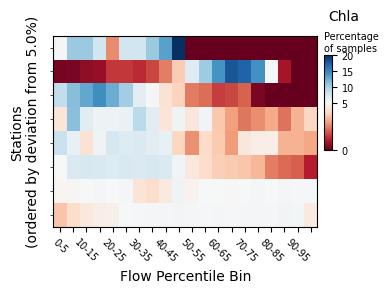

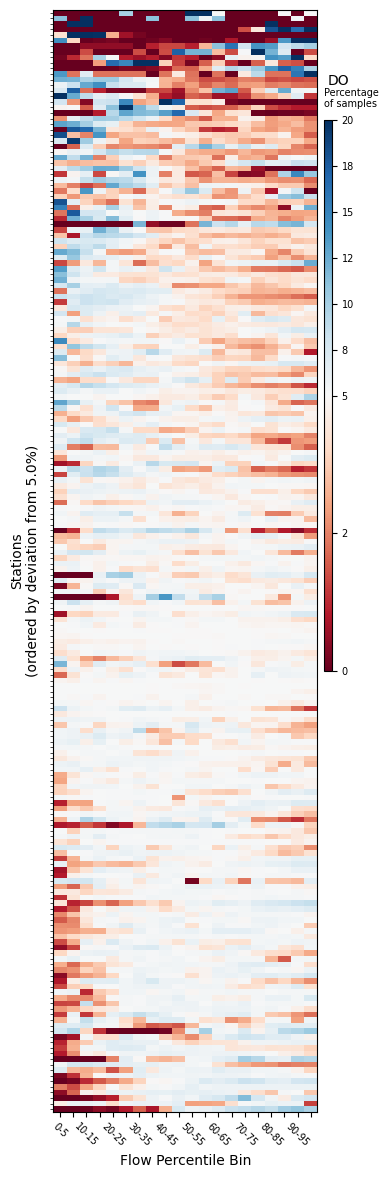

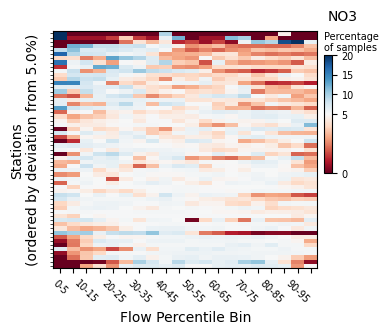

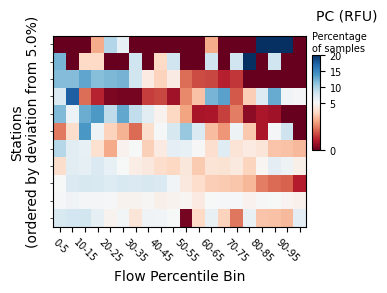

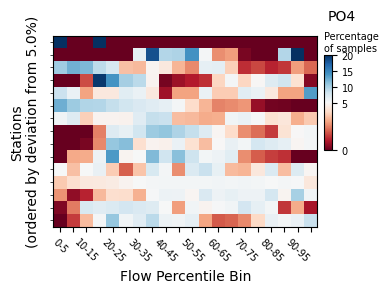

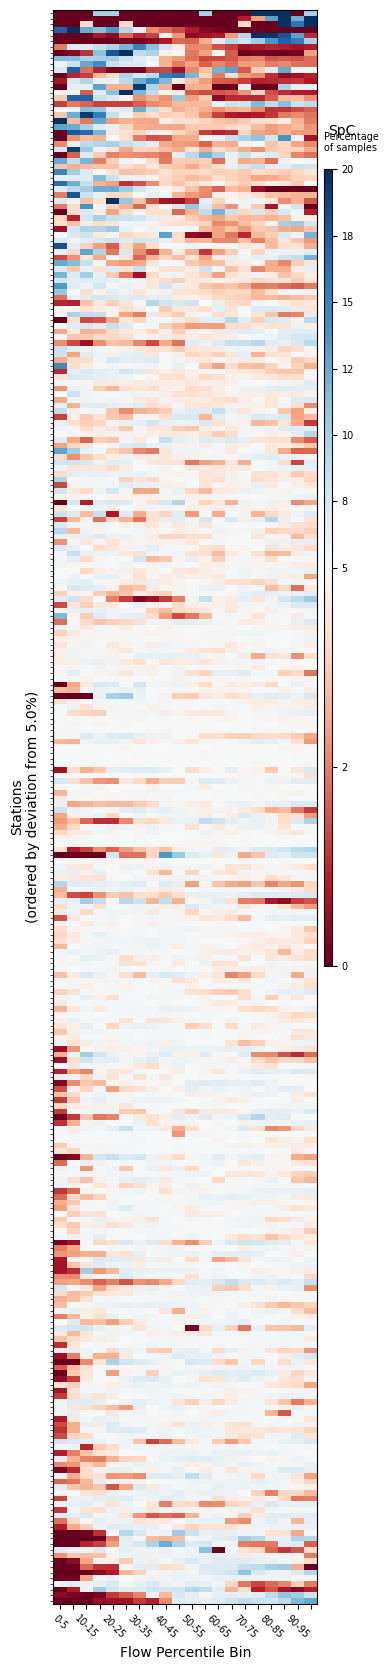

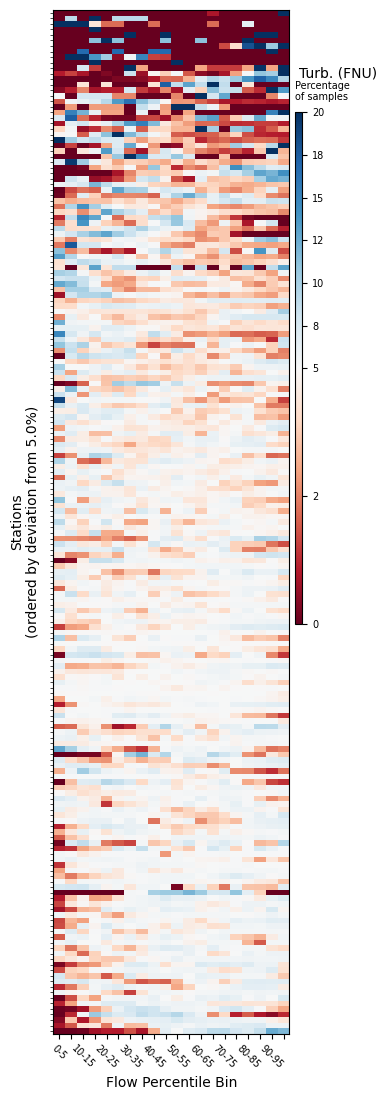

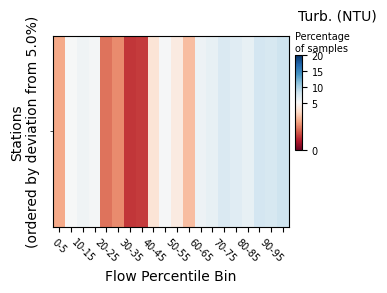

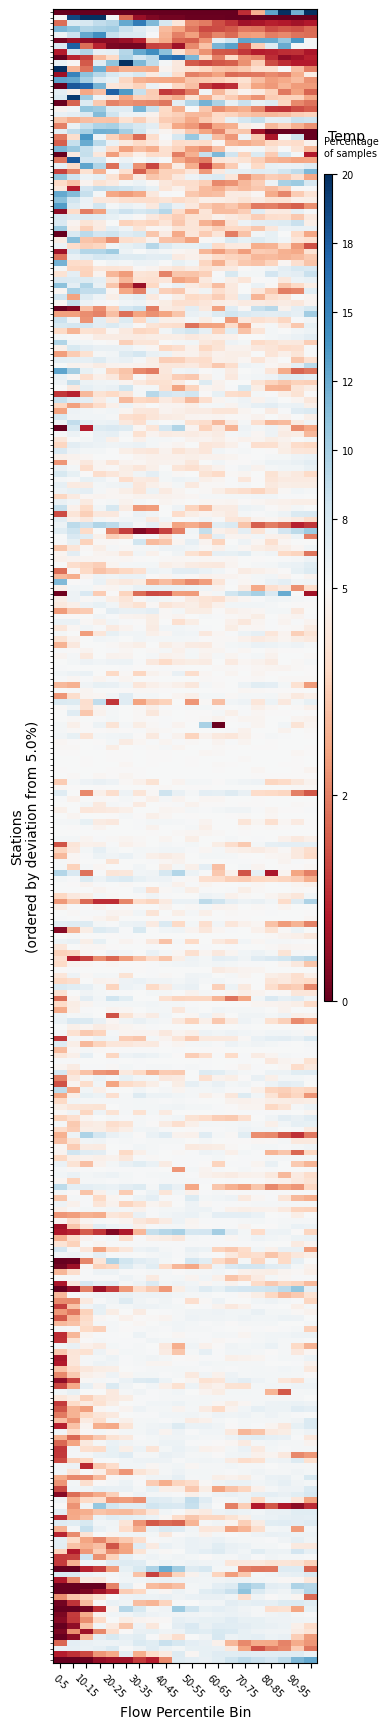

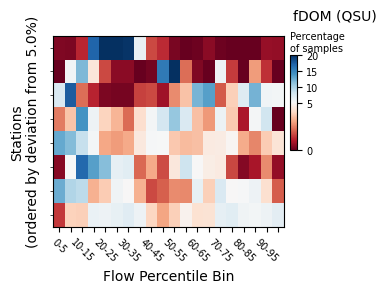

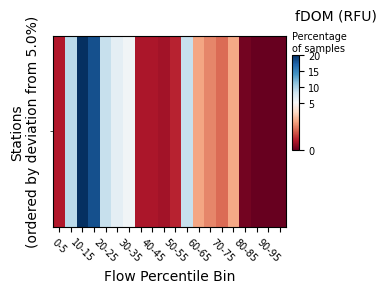

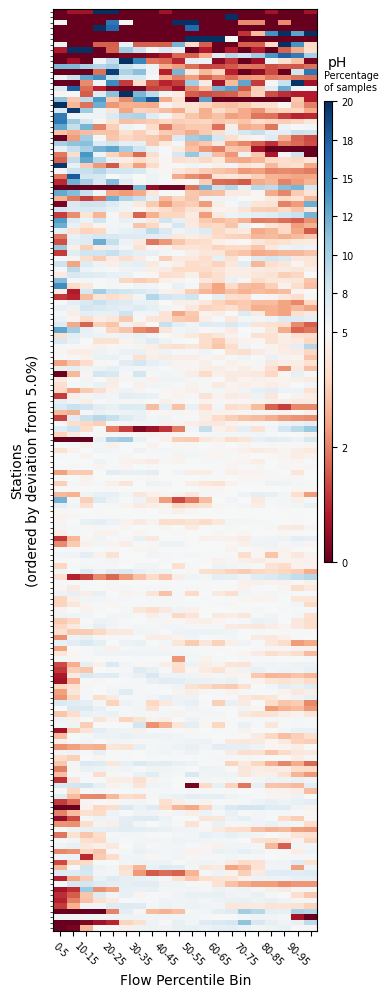

In [7]:
# Create heat map for each solute
params = {'DO_mgL':'DO (mg/L)',
          'SpC_uScm':'SpC (μS/cm)',
          'Turb_FNU':'Turbidity (FNU)'}
solute_summary = []
for solute, binned_sol in WQ_Q_binned_fractions.groupby('param'):
    
    # Currently sorted by STREAM ID (inherent). Uncomment to sort by high-flow sampling coverage.
    binned_sol = binned_sol.copy()
    binned_sol['sort_key'] = (binned_sol[bin_labels] - expected).abs().median(axis=1)
    binned_sol.sort_values('sort_key', ascending=False, inplace=True)
    binned_sol.drop(columns='sort_key', inplace=True)

    # Summary of results
    mid_cols = [l for l in bin_labels if int(l.split('-')[0]) >= 25 and int(l.split('-')[1]) <= 75]
    
    solute_summary_i = {
    'solute': solute,
    'n_sites': len(binned_sol),
    'median_n_samples': binned_sol['n_samples'].median(),
    'pct_below_10p': np.mean(binned_sol['0-5'] + binned_sol['5-10']), # Tail sampling
    'pct_above_90p': np.mean(binned_sol['90-95'] + binned_sol['95-100']), # Tail sampling
    'mean_abs_deviation': (binned_sol[bin_labels] - expected * 100).abs().mean().mean(), # Overall bias (how far from representative is sampling on average?)
    'pct_sites_no_highflow': ((binned_sol['90-95'] + binned_sol['95-100']) == 0).mean() * 100, # What fraction of sites have zero samples in the top 10% of flows?
    'peak_bin': binned_sol[bin_labels].median().idxmax(), # Where does the bulk of sampling concentrate?
    'pct_mid_flow': np.mean(binned_sol[mid_cols].sum(axis=1))  # Middle flow bias (what % of samples sit between 25th-75th percentile?)
    }
    solute_summary.append(solute_summary_i)
    
    # Extrating values
    plot_matrix = binned_sol[bin_labels].values
    site_labels = binned_sol['STREAM_ID'].values

    # Crating heatmap
    fig, ax = plt.subplots(figsize= (4, max(3, len(site_labels) * 0.06))) #(4,10)
    
    vmax = 20 # percent (cbar max range)
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=expected*100, vmax=vmax) # setting max, min, and zero place
    
    im = ax.pcolormesh(plot_matrix, cmap='RdBu', norm=norm, edgecolors='none')

    # x axis aesthethic properties
    ax.set_xticks(np.arange(n_bins) + 0.5)
    ax.set_xticklabels([label if i % 2 == 0 else '' for i, label in enumerate(bin_labels)],
                   rotation=360-45, ha='center', fontsize=7)
    ax.set_xlabel('Flow Percentile Bin')

    # y axis aesthethic properties
    ax.set_yticks(np.arange(len(site_labels)) + 0.5)
    ax.set_yticklabels([])
    ax.tick_params(axis='y', length=2, width=0.5)
    ax.set_ylabel(f'Stations\n(ordered by deviation from {round(expected*100,0)}%)')

    # color bar aesthethic properties
    cbax = ax.inset_axes([1.025, 0.4, 0.03, 0.5], transform=ax.transAxes)
    cbar = fig.colorbar(im, cax=cbax, orientation='vertical')
    cbar.ax.tick_params(labelsize=7)
    cbax.set_title(f'{params_pretty_dict[solute]}', fontsize=10, pad=25, ha='left')
    cbax.text(0.0, 1.02, 'Percentage\nof samples', fontsize=7, ha='left',
          transform=cbax.transAxes, va='bottom')
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
    
    plt.tight_layout()
    plt.savefig(f'../OUTPUT/temporal_patterns/sampling_bias_heatmap_{solute}.png', dpi=600, bbox_inches='tight')
    #plt.show()

In [8]:
solute_summary_df = pd.DataFrame(solute_summary)
solute_summary_df.to_csv(OUTPUT_filepath+'discharge_statistics.csv', index=False)